LOAD LIBRARIES

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
from PIL import Image
import random

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.layers import BatchNormalization, Activation, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported!")

✅ Libraries imported!


LOAD AND EXPLORE DATASET

In [82]:
data_dir = 'anomaly_classification'
image_dir = os.path.join(data_dir, 'images')
csv_path = os.path.join(data_dir, 'dataset.csv')

# Load CSV
df = pd.read_csv(csv_path)

print("=== DATASET INFO ===")
print(f"CSV shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

print(f"\nColumn names: {df.columns.tolist()}")

print(f"\n=== CLASS DISTRIBUTION ===")
print(f"\nNormal: {len(df[df['anomaly']==0])} images")
print(f"Anomaly: {len(df[df['anomaly']==1])} images")
print(f"Anomaly ratio: {df['anomaly'].mean():.1%}")

print(f"\n=== PATTERN TYPES ===")
print(df['pattern_type'].value_counts())

print(f"\n=== DIFFICULTY LEVELS ===")
print(df['difficulty'].value_counts())

# Prepare image paths (PNG format)
df['image_path'] = df['image_id'].apply(lambda x: os.path.join(image_dir, x))

# Verify images exist
df['image_exists'] = df['image_path'].apply(os.path.exists)
print(f"\nImages found: {df['image_exists'].sum()} / {len(df)}")

# Filter only existing images
df = df[df['image_exists']].reset_index(drop=True)

print(f"\n✅ Using {len(df)} valid images")

=== DATASET INFO ===
CSV shape: (3000, 5)

First 5 rows:
         image_id    label pattern_type  anomaly difficulty
0  img_000000.png  anomaly         dots        1       hard
1  img_000001.png   normal        waves        0       hard
2  img_000002.png  anomaly        noise        1       easy
3  img_000003.png  anomaly         grid        1     medium
4  img_000004.png  anomaly         grid        1     medium

Column names: ['image_id', 'label', 'pattern_type', 'anomaly', 'difficulty']

=== CLASS DISTRIBUTION ===

Normal: 1797 images
Anomaly: 1203 images
Anomaly ratio: 40.1%

=== PATTERN TYPES ===
pattern_type
noise      628
dots       617
waves      592
grid       591
stripes    572
Name: count, dtype: int64

=== DIFFICULTY LEVELS ===
difficulty
medium    1007
hard      1001
easy       992
Name: count, dtype: int64

Images found: 3000 / 3000

✅ Using 3000 valid images


DATA SPLIT - STRATIFY BY PATTERN TYPE

In [83]:
# Convert everything to lists 
x = df['image_path'].tolist()
y = df['anomaly'].tolist()
pattern_types = df['pattern_type'].tolist()

x_train, x_temp, y_train, y_temp, pattern_train, pattern_temp = train_test_split(
    x, y, pattern_types, test_size=0.3, random_state=42, stratify=y
)

x_val, x_test, y_val, y_test, pattern_val, pattern_test = train_test_split(
    x_temp, y_temp, pattern_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train: {len(x_train)}, Val: {len(x_val)}, Test: {len(x_test)}")

Train: 2100, Val: 450, Test: 450


In [84]:
print("\n=== CLASS DISTRIBUTION ===")
print(f"Training - Normal: {y_train.count(0)}, Anomaly: {y_train.count(1)}")
print(f"Validation - Normal: {y_val.count(0)}, Anomaly: {y_val.count(1)}")
print(f"Test - Normal: {y_test.count(0)}, Anomaly: {y_test.count(1)}")


=== CLASS DISTRIBUTION ===
Training - Normal: 1258, Anomaly: 842
Validation - Normal: 269, Anomaly: 181
Test - Normal: 270, Anomaly: 180


DATA GENERATOR AND PREPROCESSING

In [85]:
IMG_HEIGHT = 128  
IMG_WIDTH = 128
BATCH_SIZE = 32

def load_image(path, label):
    """Load PNG image, resize, normalize"""
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=3)  # PNG, not JPG!
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def augment_image(image, label):
    """Data augmentation for training"""
    # Random flip
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    
    # Random rotation (0, 90, 180, 270 degrees)
    k = tf.random.uniform([], 0, 4, dtype=tf.int32)
    image = tf.image.rot90(image, k)
    
    # Random brightness and contrast
    image = tf.image.random_brightness(image, 0.2)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    
    return image, label

# Create datasets
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
val_dataset = tf.data.Dataset.from_tensor_slices((x_val, y_val))
test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))

# Apply transformations
train_dataset = train_dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)

val_dataset = val_dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

# Batch and prefetch
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"✅ Datasets created!")
print(f"Training batches: {len(list(train_dataset.as_numpy_iterator()))}")
print(f"Validation batches: {len(list(val_dataset.as_numpy_iterator()))}")
print(f"Test batches: {len(list(test_dataset.as_numpy_iterator()))}")

✅ Datasets created!
Training batches: 66
Validation batches: 15
Test batches: 15


SAMPLE VISUALIZATION

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.16370964..0.8572408].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.21724921..0.9375747].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.04952261..0.80114377].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.03845054..0.6809908].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.11263985..0.81521976].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.06379278..0.4399582].


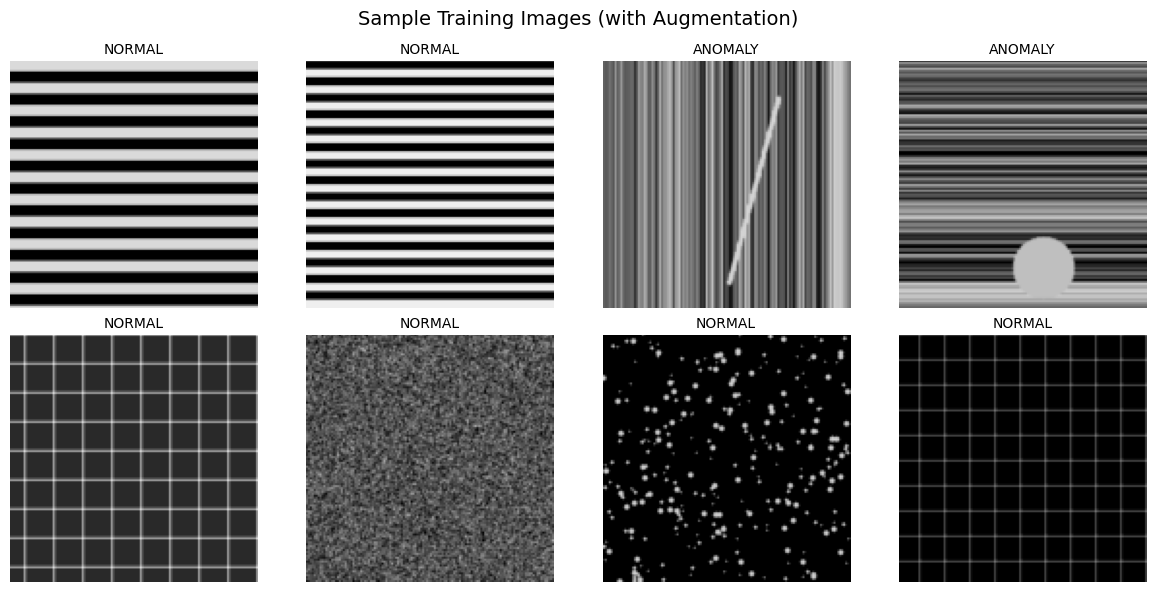

In [86]:
# Visualize sample 
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.ravel()

# Get one batch
for images, labels in train_dataset.take(1):
    # images shape: (32, 128, 128, 3)
    # Take first 8 images from the batch
    for i in range(8):
        img = images[i]  # Get single image (128, 128, 3)
        label = labels[i]
        axes[i].imshow(img)
        title = "ANOMALY" if label.numpy() == 1 else "NORMAL"
        axes[i].set_title(title, fontsize=10)
        axes[i].axis('off')

plt.suptitle("Sample Training Images (with Augmentation)", fontsize=14)
plt.tight_layout()
plt.show()

MODEL BUILDING

In [87]:
model = Sequential()

model.add(Conv2D(32, (3, 3), padding='same', use_bias=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(64, (3, 3), padding='same', use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(128, (3, 3), padding='same', use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(256, (3, 3), padding='same', use_bias=False))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(2, 2))

model.add(GlobalAveragePooling2D())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)                   │ (None, 128, 128, 32)        │             864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_24               │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_30 (Activation)           │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_25 (MaxPooling2D)      │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_31 (Conv2D)                   │ (None, 64, 64, 64)          │          18,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_25               │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_31 (Activation)           │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_26 (MaxPooling2D)      │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_32 (Conv2D)                   │ (None, 32, 32, 128)         │          73,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_26               │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_32 (Activation)           │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_27 (MaxPooling2D)      │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_33 (Conv2D)                   │ (None, 16, 16, 256)         │         294,912 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_27               │ (None, 16, 16, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_33 (Activation)           │ (None, 16, 16, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_28 (MaxPooling2D)      │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_7           │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_18 (Dropout)                 │ (None, 256)                 │              

 Total params: 488,673 (1.86 MB)

 Trainable params: 487,713 (1.86 MB)

 Non-trainable params: 960 (3.75 KB)

COMPILE MODEL

In [89]:
model.compile(
    optimizer=Adam(), 
    loss='binary_crossentropy',
    metrics=['accuracy', 'precision', 'recall', 'auc']
)

print("✅ Model compiled!")

✅ Model compiled!


MODEL TRAINING

In [90]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    verbose=1
)

print("\n✅ Training complete!")
print(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}")

Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 53s 743ms/step - accuracy: 0.5710 - auc: 0.5527 - loss: 0.7297 - precision: 0.4476 - recall: 0.2993 - val_accuracy: 0.4756 - val_auc: 0.5384 - val_loss: 0.7026 - val_precision: 0.3978 - val_recall: 0.5912
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 48s 730ms/step - accuracy: 0.5762 - auc: 0.5379 - loss: 0.6953 - precision: 0.4423 - recall: 0.2185 - val_accuracy: 0.5578 - val_auc: 0.5312 - val_loss: 0.6831 - val_precision: 0.4118 - val_recall: 0.2320
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 48s 733ms/step - accuracy: 0.5733 - auc: 0.5192 - loss: 0.6923 - precision: 0.4056 - recall: 0.1378 - val_accuracy: 0.6067 - val_auc: 0.5765 - val_loss: 0.6751 - val_precision: 0.5286 - val_recall: 0.2044
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 50s 750ms/step - accuracy: 0.5995 - auc: 0.5476 - loss: 0.6778 - precision: 0.5014 - recall: 0.2055 - val_accuracy: 0.6067 - val_auc: 0.6068 - val_loss: 0.6726 - val_precision: 0.5233 - val_recall: 0.2486
Epoch 5/50
66/66 ━━━━━━━━━━━

VISUALIZE TRAINING

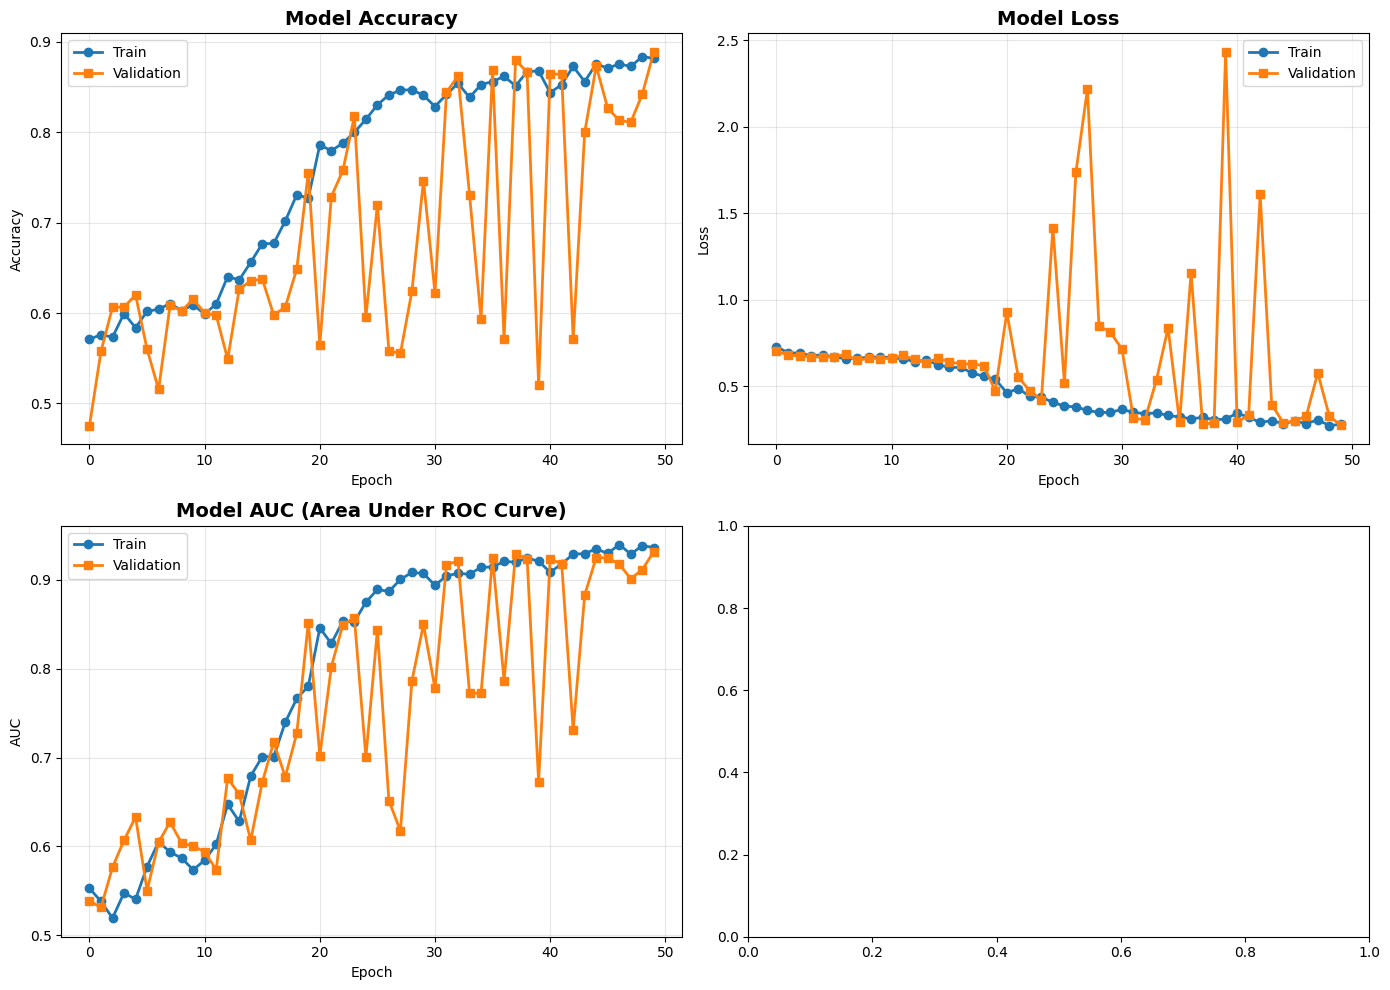

In [91]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy
axes[0, 0].plot(history.history['accuracy'], label='Train', marker='o', linewidth=2)
axes[0, 0].plot(history.history['val_accuracy'], label='Validation', marker='s', linewidth=2)
axes[0, 0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss
axes[0, 1].plot(history.history['loss'], label='Train', marker='o', linewidth=2)
axes[0, 1].plot(history.history['val_loss'], label='Validation', marker='s', linewidth=2)
axes[0, 1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# AUC
if 'auc' in history.history:
    axes[1, 0].plot(history.history['auc'], label='Train', marker='o', linewidth=2)
    axes[1, 0].plot(history.history['val_auc'], label='Validation', marker='s', linewidth=2)
    axes[1, 0].set_title('Model AUC (Area Under ROC Curve)', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('AUC')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

# Learning Rate (if using ReduceLROnPlateau)
if 'lr' in history.history:
    axes[1, 1].plot(history.history['lr'], color='green', marker='o', linewidth=2)
    axes[1, 1].set_title('Learning Rate', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Learning Rate')
    axes[1, 1].set_yscale('log')
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [92]:
# Print final metrics
print("\n=== FINAL TRAINING METRICS ===")
print(f"Training Accuracy:   {history.history['accuracy'][-1]:.4f} ({history.history['accuracy'][-1]*100:.2f}%)")
print(f"Validation Accuracy: {history.history['val_accuracy'][-1]:.4f} ({history.history['val_accuracy'][-1]*100:.2f}%)")
print(f"Training Loss:       {history.history['loss'][-1]:.4f}")
print(f"Validation Loss:     {history.history['val_loss'][-1]:.4f}")

if 'auc' in history.history:
    print(f"Training AUC:        {history.history['auc'][-1]:.4f}")
    print(f"Validation AUC:      {history.history['val_auc'][-1]:.4f}")

# Best epoch
best_epoch = np.argmax(history.history['val_accuracy']) + 1
best_acc = max(history.history['val_accuracy'])
print(f"\n🏆 Best validation accuracy: {best_acc:.4f} ({best_acc*100:.2f}%) at Epoch {best_epoch}")


=== FINAL TRAINING METRICS ===
Training Accuracy:   0.8819 (88.19%)
Validation Accuracy: 0.8889 (88.89%)
Training Loss:       0.2815
Validation Loss:     0.2753
Training AUC:        0.9364
Validation AUC:      0.9319

🏆 Best validation accuracy: 0.8889 (88.89%) at Epoch 50


TEST SET EVALUATION

In [93]:
test_loss, test_acc, test_precision, test_recall, test_auc = model.evaluate(test_dataset)

print(f"Accuracy: {test_acc:.2%}")  
print(f"Precision: {test_precision:.2%}")  
print(f"Recall: {test_recall:.2%}") 
print(f"AUC: {test_auc:.2%}") 

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 182ms/step - accuracy: 0.8978 - auc: 0.9520 - loss: 0.2692 - precision: 0.9036 - recall: 0.8333
Accuracy: 89.78%
Precision: 90.36%
Recall: 83.33%
AUC: 95.20%


In [94]:
y_true = []      
y_pred = []      
y_pred_proba = []  

for images, labels in test_dataset:
    predictions = model.predict(images)
    y_pred_proba.extend(predictions)  
    y_pred.extend([1 if p>0.5 else 0 for p in predictions])  
    y_true.extend(labels)  

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step


In [95]:
cm = confusion_matrix(y_true, y_pred) 
print(cm)

[[254  16]
 [ 30 150]]


In [96]:
cr = classification_report(y_true, y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.89      0.94      0.92       270
           1       0.90      0.83      0.87       180

    accuracy                           0.90       450
   macro avg       0.90      0.89      0.89       450
weighted avg       0.90      0.90      0.90       450



In [97]:
fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
roc_auc = auc(fpr, tpr)
print(roc_auc)

0.9520164609053499
